# YOLO training test

Use this notebook locally or on an Azure ML compute instance to verify an end-to-end Ultralytics YOLO training flow before submitting the managed production job.

The default run uses the public COCO8 object-detection dataset, YOLO11 nano, one CPU epoch, and small images. Local execution incurs no Azure compute cost. An Azure ML compute instance continues to incur charges until you stop it.

Run the cells from top to bottom. For customer data, change `CUSTOM_DATA_YAML` in the configuration cell to the dataset's `data.yaml`. Generated models and results are written to the ignored `notebook-output/` directory.

## 1. Prerequisites

For local use, select the repository's Python 3.12 `.venv` kernel created from `pyproject.toml`. On Azure ML, use a kernel with internet access for the first model and dataset download; the installation cell can add a compatible Ultralytics 8.x release.

Keep `DEVICE = "cpu"` for the lowest-cost smoke test. For GPU testing, select GPU-backed compute and set `DEVICE = 0`. Stop any Azure ML compute instance as soon as you finish.

In [1]:
from pathlib import Path

DATASET_PRESET = "coco8"
CUSTOM_DATA_YAML = None
# Example continuous snapshot:
# CUSTOM_DATA_YAML = "data/continuous-simulation/snapshots/version-001/data.yaml"
ENABLE_VALIDATION = True

DATASET_OPTIONS = {
    "coco8": {"yaml": "coco8.yaml", "train": "train", "validation": "val"},
    "coco128": {"yaml": "coco128.yaml", "train": "train", "validation": "val"},
    "visdrone": {"yaml": "VisDrone.yaml", "train": "train", "validation": "val"},
    "voc": {"yaml": "VOC.yaml", "train": "train", "validation": "val"},
}
if DATASET_PRESET not in DATASET_OPTIONS:
    raise ValueError(f"DATASET_PRESET must be one of {sorted(DATASET_OPTIONS)}")

selected_dataset = DATASET_OPTIONS[DATASET_PRESET]
DATA_YAML = CUSTOM_DATA_YAML or selected_dataset["yaml"]
TRAIN_SPLIT = selected_dataset["train"]
VALIDATION_SPLIT = selected_dataset["validation"]
DATASET_NAME = "custom" if CUSTOM_DATA_YAML else DATASET_PRESET

MODEL = "yolo11n.pt"
EPOCHS = 1
IMAGE_SIZE = 320
BATCH_SIZE = 4
DEVICE = "cpu"  # Use 0 on a GPU-backed compute instance.
OUTPUT_DIR = Path("notebook-output")
RUN_NAME = "run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Available datasets: {', '.join(DATASET_OPTIONS)}")
print(f"Selected dataset: {DATASET_NAME} -> {DATA_YAML}")
print(f"Training split: {TRAIN_SPLIT}")
print(f"Validation split: {VALIDATION_SPLIT} (enabled: {ENABLE_VALIDATION})")
print(f"Model: {MODEL}")
print(f"Output: {OUTPUT_DIR.resolve()}")

Available datasets: coco8, coco128, visdrone, voc
Selected dataset: coco8 -> coco8.yaml
Training split: train
Validation split: val (enabled: True)
Model: yolo11n.pt
Output: /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/notebook-output


In [2]:
import platform
import sys
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
try:
    import torch
except ImportError:
    print("PyTorch is not installed yet. Run the installation cell below.")
else:
    print(f"PyTorch: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.10.0
Platform: Linux-6.8.0-1059-azure-x86_64-with-glibc2.35
PyTorch: 2.1.2+cu121
CUDA available: True
GPU: Tesla M60


In [3]:
try:
    import ultralytics
except ImportError:
    %pip install "ultralytics>=8.4,<9"
    print("Ultralytics installed. Restart the kernel if the next import fails.")
else:
    print(f"Ultralytics: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 44.9 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: psutil
    Found existing installation: psutil 5.2.2
    Uninstalling psutil-5.2.2:
      Successfully uninstalled psutil-5.2.2
  Attempting uninstall: cloudpickle━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [polars-runtime-32]
    Found existing installation: cloudpickle 1.6.0━━━━━━━━━━━━ 1/6 [polars-runtime-32]
    Uninstalling cloudpickle-1.6.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [polars-runtime-32]
      Successfully uninstalled cloudpickle-1.6.0━━━━━━━━━━━━━━ 1/6 [polars-runtime-32]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [ultralytics] [ultralytics]2]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

In [4]:
if CUSTOM_DATA_YAML:
    from src.validate_dataset import validate_dataset

    validation_summary = validate_dataset(Path(CUSTOM_DATA_YAML))
    print(f"Custom dataset contract passed: {validation_summary}")
else:
    print("Preset selected; repository dataset validation is skipped.")

Preset selected; repository dataset validation is skipped.


## 2. Choose the dataset

Set `DATASET_PRESET` in the configuration cell. The selected Ultralytics YAML supplies its training and validation splits automatically:

| Option | Training split | Validation split | Approximate size |
| --- | ---: | ---: | ---: |
| `coco8` | 4 images | 4 images | Minimal smoke test |
| `coco128` | 128 images | Same 128 images | About 7 MB |
| `visdrone` | 6,471 images | 548 images | About 2 GB |
| `voc` | 16,551 images | 4,952 VOC 2007 test images | About 2.8 GB |

Set `ENABLE_VALIDATION = True` to validate against the selected dataset's `val` split during training. COCO128's standard preset reuses training images for validation, so its metrics are optimistic.

For the continuous-training simulation, first run `python scripts/simulate_arrivals.py`, then set `CUSTOM_DATA_YAML` to a generated snapshot such as `data/continuous-simulation/snapshots/version-001/data.yaml`. These snapshots use a fixed 26-image validation split and cumulative training sets of 25, 50, 75, and 100 images.

When `CUSTOM_DATA_YAML` is set, the preceding validation cell applies the same image, label, class, bounding-box, and split-overlap checks used by the managed Azure ML CPU validation job.

Ultralytics downloads and converts a selected preset automatically. Use GPU-backed compute for VisDrone or Pascal VOC, retain at least 10 GB of free disk space, and begin with one epoch.

A custom dataset must use this structure:

```text
customer-data/
  data.yaml
  images/train/
  images/val/
  labels/train/
  labels/val/
```

Every image needs a same-named `.txt` label. Each object line uses `class_id x_center y_center width height`, with coordinates normalized from 0 to 1.


## 3. Train the model

This cell is compute-intensive. Local CPU execution has no Azure compute charge; Azure ML compute is billable while active. Confirm the selected dataset and settings first, start with one epoch, and increase `EPOCHS` only after the flow succeeds.

In [5]:
from ultralytics import YOLO

model = YOLO(MODEL)
training_results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    val=ENABLE_VALIDATION,
    project=str(OUTPUT_DIR / "training"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

run_dir = Path(training_results.save_dir)
best_model_path = run_dir / "weights" / "best.pt"
print(f"Run directory: {run_dir.resolve()}")
print(f"Best model: {best_model_path.resolve()}")

WARNING ⚠️ user config directory '/home/azureuser/.config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.10.0 torch-2.1.2+cu121 CPU (Intel Xeon CPU E5-2690 v4 @ 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropo

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.
2026/09/14 03:50:32 INFO mlflow.tracking.fluent: Experiment with name 'notebook-output/training' does not exist. Creating a new experiment.
2026/09/14 03:50:32 WARNING mlflow.utils.autologging_utils: MLflow transformers autologging is known to be compatible with 4.35.2 <= transformers <= 4.51.2, but the installed version is 4.53.0. If you encounter errors during autologging, try upgrading / downgrading transformers to a compatible version, or try upgrading MLflow.
2026/09/14 03:50:36 INFO mlflow.bedrock: Enabled auto-tracing for Bedrock. Note that MLflow can only trace boto3 service clients that are created after this call. If you have already created one, please rec

## 4. Review training metrics
For a smoke test, success means the run completes and creates `best.pt`. Do not use one-epoch COCO8 metrics to judge production accuracy. For customer training, compare precision, recall, mAP50, and mAP50-95 across model and data versions.

In [6]:
if not best_model_path.exists():
    raise FileNotFoundError(f"Training did not produce {best_model_path}")
metrics = getattr(training_results, "results_dict", {}) or {}
if metrics:
    for metric_name, metric_value in metrics.items():
        if isinstance(metric_value, (int, float)):
            print(f"{metric_name}: {metric_value:.4f}")
else:
    print("No summary dictionary was returned; review results.csv in the run directory.")
results_csv = run_dir / "results.csv"
print(f"Metrics history: {results_csv.resolve()}")

metrics/precision(B): 0.6437
metrics/recall(B): 0.5667
metrics/mAP50(B): 0.6844
metrics/mAP50-95(B): 0.3999
fitness: 0.3999
Metrics history: /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/runs/detect/notebook-output/training/run/results.csv


## 5. Validation behavior

Two validation layers serve different purposes. Before training, `src.validate_dataset.validate_dataset()` checks a custom dataset's files, labels, class IDs, normalized boxes, and split isolation; the managed flow runs the equivalent check as a low-cost Azure ML CPU job. During training, `ENABLE_VALIDATION` controls whether Ultralytics evaluates model precision, recall, mAP50, and mAP50-95 against the configured `val` split. Passing the dataset contract does not imply acceptable model quality.

In [7]:
if ENABLE_VALIDATION:
    print(f"Validation completed during training with {DATASET_NAME}:{VALIDATION_SPLIT}.")
    print(f"Training and validation artifacts: {run_dir.resolve()}")
else:
    print("Validation was disabled. Set ENABLE_VALIDATION = True and rerun training to enable it.")

Validation completed during training with coco8:val.
Training and validation artifacts: /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/runs/detect/notebook-output/training/run


## 6. Run a sample prediction
Set `PREDICTION_SOURCE` to a local customer image when available. The default public image keeps the COCO8 path easy to test. Predictions are saved under the notebook output directory.

In [8]:
PREDICTION_SOURCE = "https://ultralytics.com/images/bus.jpg"
trained_model = YOLO(best_model_path)
prediction_results = trained_model.predict(
    source=PREDICTION_SOURCE,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    conf=0.25,
    save=True,
    project=str(OUTPUT_DIR / "predictions"),
    name="sample",
    exist_ok=True,
)
prediction = prediction_results[0]
print(f"Detected objects: {0 if prediction.boxes is None else len(prediction.boxes)}")
print(f"Saved prediction directory: {Path(prediction.save_dir).resolve()}")


image 1/1 /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/bus.jpg: 320x256 4 persons, 1 bus, 62.4ms
Speed: 6.6ms preprocess, 62.4ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 256)
Results saved to /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/runs/detect/notebook-output/predictions/sample
Detected objects: 5
Saved prediction directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/runs/detect/notebook-output/predictions/sample


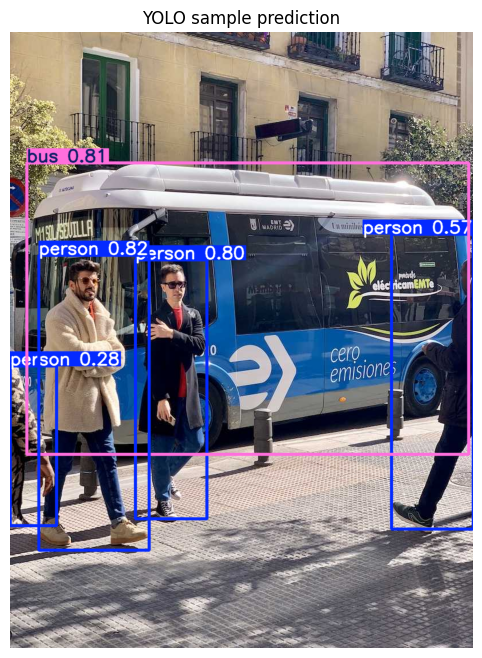

In [9]:
import matplotlib.pyplot as plt
annotated_image = prediction.plot()[:, :, ::-1]
plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLO sample prediction")
plt.show()

## 7. Export the test model
Copy the best checkpoint to the same stable `model.pt` name used by the automated Azure ML training job. This makes the notebook output easy to inspect or register as a test model.

In [10]:
import shutil
exported_model = OUTPUT_DIR / "model.pt"
shutil.copy2(best_model_path, exported_model)
print(f"Exported model: {exported_model.resolve()}")
print(f"Size: {exported_model.stat().st_size / (1024 * 1024):.2f} MB")

Exported model: /mnt/batch/tasks/shared/LS_root/mounts/clusters/waimanhui1/code/Users/waimanhui/notebook-output/model.pt
Size: 5.24 MB


## Next step: use the managed MLOps flow

This notebook is for interactive training, validation, metrics, and prediction. It does not replace the reproducible Azure ML jobs or GitHub workflows.

For manual production training:

1. Register an immutable `yolo-training-data` version.
2. Submit `azureml/jobs/train.yml` or run **Retrain YOLO**.
3. Review the managed metrics and registered `yolo-detector` version.
4. Deploy an approved version through **Deploy YOLO Batch Model**.

For continuous-training testing:

1. Run **Set Up Continuous Training** once.
2. Run **Simulate Continuous Dataset Arrivals**.
3. Run **Process Continuous Training Batches** with `max_batches = 2` and `training_profile = test`.
4. Review the resulting `yolo-detector-test` versions and lineage tags.
5. Keep production deployment behind the protected approval workflow.

Stop any Azure ML compute instance when finished. Managed CPU and GPU clusters in this repository scale down to zero.